In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os
import logging
import joblib
import random

%load_ext autoreload
%autoreload 2

In [ ]:
def set_seed(seed: int = 42):
    """
    Sets the random seed for reproducibility across multiple libraries.

    Args:
        seed (int): The seed value to use. Default is 42.
    """
    random.seed(seed)  # Python's built-in random module
    np.random.seed(seed)  # NumPy
    torch.manual_seed(seed)  # PyTorch CPU
    torch.cuda.manual_seed(seed)  # PyTorch GPU (single-GPU)
    torch.cuda.manual_seed_all(seed)  # PyTorch (multi-GPU)

    # Ensure deterministic behavior in CUDA (if applicable)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Slows down training but ensures reproducibility

    print(f"Random seed set to: {seed}")

# Example usage
set_seed(42)

def visualization (ori_data, generated_data, analysis):
  """Using PCA or tSNE for generated and original data visualization.

  Args:
    - ori_data: original data
    - generated_data: generated synthetic data
    - analysis: tsne or pca
  """
  # Analysis sample size (for faster computation)
  anal_sample_no = min([1000, len(ori_data)])
  idx = np.random.permutation(len(ori_data))[:anal_sample_no]

  # Data preprocessing
  ori_data = np.asarray(ori_data)
  generated_data = np.asarray(generated_data)

  ori_data = ori_data[idx]
  generated_data = generated_data[idx]

  no, seq_len, dim = ori_data.shape

  for i in range(anal_sample_no):
    if (i == 0):
      prep_data = np.reshape(np.mean(ori_data[0,:,:], 1), [1,seq_len])
      prep_data_hat = np.reshape(np.mean(generated_data[0,:,:],1), [1,seq_len])
    else:
      prep_data = np.concatenate((prep_data,
                                  np.reshape(np.mean(ori_data[i,:,:],1), [1,seq_len])))
      prep_data_hat = np.concatenate((prep_data_hat,
                                      np.reshape(np.mean(generated_data[i,:,:],1), [1,seq_len])))

  # Visualization parameter
  colors = ["red" for i in range(anal_sample_no)] + ["blue" for i in range(anal_sample_no)]

  if analysis == 'pca':
    # PCA Analysis
    pca = PCA(n_components = 2, random_state=42)
    pca.fit(prep_data)
    pca_results = pca.transform(prep_data)
    pca_hat_results = pca.transform(prep_data_hat)

    # Plotting
    f, ax = plt.subplots(1)
    plt.scatter(pca_results[:,0], pca_results[:,1],
                c = colors[:anal_sample_no], alpha = 0.2, label = "Original")
    plt.scatter(pca_hat_results[:,0], pca_hat_results[:,1],
                c = colors[anal_sample_no:], alpha = 0.2, label = "Synthetic")

    ax.legend()
    plt.title('PCA plot')
    plt.xlabel('x-pca')
    plt.ylabel('y_pca')
    plt.show()

  elif analysis == 'tsne':

    # Do t-SNE Analysis together
    prep_data_final = np.concatenate((prep_data, prep_data_hat), axis = 0)

    # TSNE anlaysis
    tsne = TSNE(n_components = 2, random_state=42)
    tsne_results = tsne.fit_transform(prep_data_final)

    # Plotting
    f, ax = plt.subplots(1)

    plt.scatter(tsne_results[:anal_sample_no,0], tsne_results[:anal_sample_no,1],
                c = colors[:anal_sample_no], alpha = 0.2, label = "Original")
    plt.scatter(tsne_results[anal_sample_no:,0], tsne_results[anal_sample_no:,1],
                c = colors[anal_sample_no:], alpha = 0.2, label = "Synthetic")

    ax.legend()

    plt.title('t-SNE plot')
    plt.xlabel('x-tsne')
    plt.ylabel('y_tsne')
    plt.show()

Random seed set to: 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

root = '/content/drive/MyDrive/Colab_Notebooks/volatility_trading/sequence_generation'
os.chdir(root)
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Notebooks/volatility_trading/sequence_generation


In [ ]:
# Ensure the 'logs' directory exists
os.makedirs("logs", exist_ok=True)  # Creates the 'logs' directory if it doesn't exist

# Configure the logger
logging.basicConfig(
    level=logging.DEBUG,  # Set to DEBUG to capture all log messages
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("logs/model_training.log"),  # Save logs to file
        logging.StreamHandler()  # Also print logs to console
    ]
)

# Create a logger instance
logger = logging.getLogger(__name__)

logger.info("Logger setup complete. Logging will be written to logs/model_training.log")

In [1]:
from timegan import TimeSeriesDataset, TimeGAN

ModuleNotFoundError: No module named 'timegan'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256

In [ ]:
data_path = 'data/VIX_History.csv'
scaler_path='models/scaler.pkl'

# Load and preprocess the data
all_data = pd.read_csv(data_path)
all_data.drop(['DATE'], axis=1, inplace=True)

seq_len = 5
n_seq = all_data.shape[1]

# Create dataset object
dataset = TimeSeriesDataset(all_data, seq_len, n_seq, scaler_path=scaler_path)

# Get train, val, test datasets
train_dataset, val_dataset, test_dataset = dataset.get_datasets()

# Create DataLoaders (optional)
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Initializing TimeSeriesDataset...
Data split: 7092 train, 886 validation, 887 test
Scaler saved at models/scaler.pkl


In [ ]:
# Initialize TimeGAN
learning_rate = 2e-4
dim = len(train_dataset)
input_dim = train_dataset[0].shape[1]
hidden_dim = 32
n_layers = 4
train_steps = 400

model = TimeGAN(input_dim=input_dim, hidden_dim=hidden_dim, n_layers=n_layers,
                seq_len=seq_len, n_seq=n_seq, batch_size=batch_size,
                lr=learning_rate, device=device)

Logger setup complete. Logging will be written to logs/model_training.log
Model initialized with ID: _20250223_222339_3bdb5424)_n_layers4_seq_len5_n_seq4


In [ ]:
model.train_autoencoder(train_loader, val_loader, epochs=train_steps)

Training AutoEncoder
epoch [1/400], train loss: 0.065927, val loss: 0.021672, lr: 0.0001999984578822395
Best autoencoder model saved with loss 0.021672
epoch [2/400], train loss: 0.028892, val loss: 0.025095, lr: 0.00019999383162408305
epoch [3/400], train loss: 0.026074, val loss: 0.024939, lr: 0.00019998612151090006
epoch [4/400], train loss: 0.025146, val loss: 0.023684, lr: 0.0001999753280182866
epoch [5/400], train loss: 0.023787, val loss: 0.021736, lr: 0.00019996145181203615
epoch [6/400], train loss: 0.022553, val loss: 0.018639, lr: 0.00019994449374809853
Best autoencoder model saved with loss 0.018639
epoch [7/400], train loss: 0.020767, val loss: 0.015208, lr: 0.00019992445487252694
Best autoencoder model saved with loss 0.015208
epoch [8/400], train loss: 0.018871, val loss: 0.012536, lr: 0.00019990133642141362
Best autoencoder model saved with loss 0.012536
epoch [9/400], train loss: 0.017576, val loss: 0.011092, lr: 0.00019987513982081356
Best autoencoder model saved with

In [ ]:
model.train_supervisor(train_loader, val_loader, epochs=train_steps)

Training Supervisor model...
epoch [1/400], train loss: 0.075627, val loss: 0.025233, lr: 0.0001999984578822395
Best Supervisor model saved with validation loss 0.025233
epoch [2/400], train loss: 0.046217, val loss: 0.015048, lr: 0.00019999383162408305
Best Supervisor model saved with validation loss 0.015048
epoch [3/400], train loss: 0.037872, val loss: 0.010774, lr: 0.00019998612151090006
Best Supervisor model saved with validation loss 0.010774
epoch [4/400], train loss: 0.033329, val loss: 0.008358, lr: 0.0001999753280182866
Best Supervisor model saved with validation loss 0.008358
epoch [5/400], train loss: 0.029998, val loss: 0.006909, lr: 0.00019996145181203615
Best Supervisor model saved with validation loss 0.006909
epoch [6/400], train loss: 0.027503, val loss: 0.006080, lr: 0.00019994449374809853
Best Supervisor model saved with validation loss 0.006080
epoch [7/400], train loss: 0.025514, val loss: 0.005469, lr: 0.00019992445487252694
Best Supervisor model saved with vali

In [ ]:
model.train_joint_network(train_loader, val_loader, epochs=150)

Training Joint Network.
Epoch [1/150], Step [0/28], d_loss: 2.4096, g_loss_u: 0.3910, g_loss_s: 0.0202, g_loss_v: 0.3902, e_loss_t0: 0.0031
Epoch [1/150], Validation Loss: 0.618810
Best models saved with loss 0.618810
Epoch [2/150], Step [0/28], d_loss: 1.6086, g_loss_u: 1.0063, g_loss_s: 0.0418, g_loss_v: 0.1889, e_loss_t0: 0.0077
Epoch [2/150], Validation Loss: 0.616399
Best models saved with loss 0.616399
Epoch [3/150], Step [0/28], d_loss: 1.7167, g_loss_u: 0.9504, g_loss_s: 0.0292, g_loss_v: 0.1620, e_loss_t0: 0.0090
Epoch [3/150], Validation Loss: 0.603640
Best models saved with loss 0.603640
Epoch [4/150], Step [0/28], d_loss: 1.5996, g_loss_u: 0.9601, g_loss_s: 0.0298, g_loss_v: 0.1553, e_loss_t0: 0.0069
Epoch [4/150], Validation Loss: 0.601066
Best models saved with loss 0.601066
Epoch [5/150], Step [0/28], d_loss: 1.5514, g_loss_u: 0.9645, g_loss_s: 0.0256, g_loss_v: 0.1589, e_loss_t0: 0.0060
Epoch [5/150], Validation Loss: 0.594117
Best models saved with loss 0.594117
Epoch 

In [ ]:
sample_size = 500
idx = np.random.permutation(len(test_dataset))[:sample_size]

real_sample = np.asarray(test_dataset)[idx] # (n, seq_len, n_seq)

synth_data = model.sample(sample_size)
synthetic_sample = np.asarray(synth_data) # (n, seq_len, n_seq)

# Load the saved scaler
scaler = joblib.load('models/scaler.pkl')

# Reshape (n, seq_len, n_seq) → (n * seq_len, n_seq) before inverse transformation
real_sample_reshaped = real_sample.reshape(-1, real_sample.shape[-1])

# Apply inverse transform
real_sample_original = scaler.inverse_transform(real_sample_reshaped)

# Reshape back to (n, seq_len, n_seq)
real_sample = real_sample_original.reshape(real_sample.shape)

Loaded best Encoder from models/best_encoder_final.pth
Loaded best Decoder from models/best_decoder_final.pth
Loaded best Generator from models/best_generator_final.pth
Loaded best Supervisor from models/best_supervisor_final.pth
Loaded best Discriminator from models/best_discriminator_final.pth


Synthetic data generation: 100%|██████████| 2/2 [00:00<00:00, 619.22it/s]


In [ ]:
real_sample.shape, synthetic_sample.shape

((500, 5, 4), (500, 5, 4))

In [ ]:
real_sample[0], synthetic_sample[0]

(array([[15.590001, 17.02    , 14.950001, 16.48    ],
        [17.23    , 17.69    , 16.439999, 17.220001],
        [17.43    , 18.57    , 17.21    , 17.78    ],
        [17.74    , 19.9     , 17.22    , 18.730001],
        [18.34    , 18.39    , 17.27    , 17.66    ]], dtype=float32),
 array([[55.54106 , 63.682724, 55.166656, 59.511456],
        [64.63621 , 75.270996, 63.43224 , 69.42127 ],
        [67.46272 , 78.4408  , 65.59126 , 72.03451 ],
        [68.353096, 79.377525, 66.21913 , 72.7912  ],
        [68.54698 , 79.59256 , 66.363144, 72.96153 ]], dtype=float32))

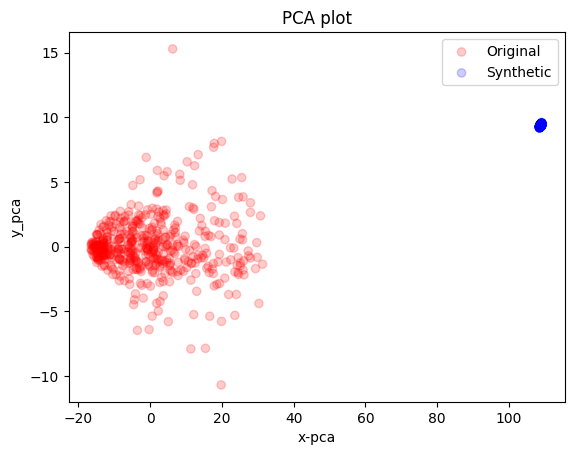

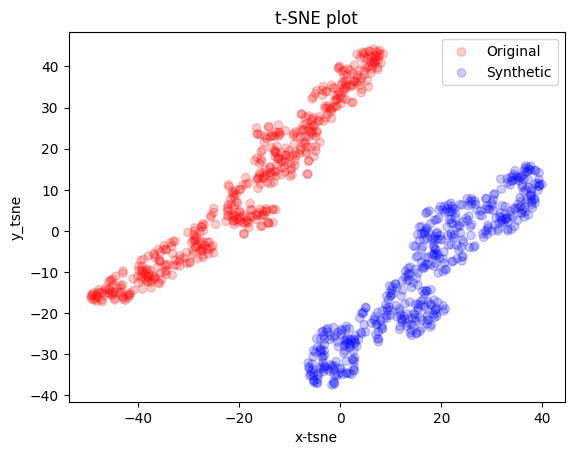

(None, None)

In [ ]:
visualization(real_sample, synthetic_sample, 'pca'), visualization(real_sample, synthetic_sample, 'tsne')